In [ ]:
!pip install torch_dct kornia

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_dct import dct_2d
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms.functional as TF
from PIL import Image

import numpy as np
import kornia
import matplotlib.pyplot as plt

import random
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [ ]:
class CustomDataset(Dataset):
  def __init__(self, img_dir, img_size=128, bit_length=64):
    self.img_paths = [os.path.join(img_dir, f) for f in os.listdir(img_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
    self.bit_length = bit_length
    self.img_transformer = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
    ])
  def __len__(self):
    return len(self.img_paths)
  def __getitem__(self, idx):
    image = Image.open(self.img_paths[idx]).convert('RGB')
    image = self.img_transformer(image)

    watermark = torch.randint(0, 2, (self.bit_length,)).float()
    return image, watermark

train_dataset = CustomDataset(img_dir='/content/drive/MyDrive/Colab Notebooks/dataset/rowsformer/DIV2K_train_HR', img_size=128, bit_length=64)
valid_dataset = CustomDataset(img_dir='/content/drive/MyDrive/Colab Notebooks/dataset/rowsformer/DIV2K_valid_HR', img_size=128, bit_length=64)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
class LocalFeatureExtractor(nn.Module):
  def __init__(self, in_channels=3, out_dim=64):
    super().__init__()
    self.in_channels = in_channels
    self.out_dims = out_dim
    # Simple convolution to extract local features
    self.conv = nn.Conv2d(in_channels, out_dim, kernel_size=3, padding=1, stride=1)
  def forward(self, x):
    # x's shape: (batch, 3, height, width)
    extracted_features = self.conv(x) # (batch, out_dims, height, width)
    return extracted_features

In [ ]:
from math import sqrt, ceil
class WatermarkEncoder(nn.Module):
  def __init__(self, watermark_length=64, out_dim=32, l1=256):
    super().__init__()
    self.watermark_length = watermark_length
    self.out_dim = out_dim
    self.l1 = l1
    self.grid_h = int(ceil(sqrt(l1)))
    self.grid_w = int(ceil(l1 / self.grid_h))
    self.grid_size = self.grid_h * self.grid_w
    self.linear = nn.Linear(watermark_length, self.grid_size)
    self.conv = nn.Conv2d(1, out_dim, kernel_size=3, padding=1)
  def forward(self, watermark, target_size):
    # watermark's shape (batch, watermark_length)
    batch = watermark.shape[0]
    x = self.linear(watermark)  # (batch, grid_size)
    x = x.view(batch, 1, self.grid_h, self.grid_w)  # (batch, 1, grid_h, grid_w)
    x = F.interpolate(x, size=target_size, mode='bilinear', align_corners=False)  # (batch, 1, H, W)
    return self.conv(x)  # (batch, out_dim, H, W)

In [ ]:
def window_partition(x, window_size):
  # Non overlapping window
  batch, num_features, height, width = x.shape
  x = x.view(batch, num_features, height // window_size, window_size, width // window_size, window_size)
  windows = x.permute(0, 2, 4, 1, 3, 5).contiguous()

  windows = windows.view(-1, num_features, window_size, window_size) # (batch * num_windows, num_features, window_size, window_size)
  return windows

def window_reverse(windows, window_size, height, width):
  batch_window, num_features, _, _ = windows.shape
  batch = batch_window // ((height // window_size) * (width // window_size))
  x = windows.view(batch, height // window_size, width // window_size, num_features, window_size, window_size)
  x = x.permute(0, 3, 1, 4, 2, 5)
  x = x.contiguous().view(batch, num_features, height, width)
  return x

In [ ]:
class WindowAttention(nn.Module):
  def __init__(self, dim, window_size=8, num_heads=4):
    super().__init__()
    assert dim % num_heads == 0, 'dim must be divisible by num_heads'
    self.dim = dim
    self.window_size = window_size
    self.num_heads = num_heads
    self.head_dim = dim // num_heads

    self.w_q = nn.Linear(dim, dim)
    self.w_k = nn.Linear(dim, dim)
    self.w_v = nn.Linear(dim, dim)
    self.out_proj = nn.Linear(dim, dim)

    Wh = window_size
    Ww = window_size
    self.rel_pos_table = nn.Parameter(
        torch.zeros((2 * Wh - 1) * (2 * Ww - 1), num_heads)
    )
    nn.init.trunc_normal_(self.rel_pos_table, std=0.02)

    coords_h = torch.arange(Wh)
    coords_w = torch.arange(Ww)
    coords = torch.stack(torch.meshgrid(coords_h, coords_w, indexing='ij'))  # (2, Wh, Ww)
    coords_flat = torch.flatten(coords, 1)  # (2, Wh*Ww)

    # Pairwise differences: (2, Wh*Ww, Wh*Ww)
    rel_coords = coords_flat[:, :, None] - coords_flat[:, None, :]
    rel_coords[0] += Wh - 1   # shift to [0, 2Wh-2]
    rel_coords[1] += Ww - 1   # shift to [0, 2Ww-2]
    rel_coords[0] *= 2 * Ww - 1

    rel_pos_index = rel_coords.sum(0)
    self.register_buffer("rel_pos_index", rel_pos_index)

  def _get_rel_pos_bias(self, batch_windows):

    seq_len = self.window_size * self.window_size

    rel_bias = self.rel_pos_table[self.rel_pos_index.view(-1)].view(seq_len, seq_len, self.num_heads)
    rel_bias = rel_bias.permute(2, 0, 1).contiguous().unsqueeze(0)  # (1, num_heads, W*W, W*W)
    return rel_bias

  def forward(self, x): # x: (batch * num_windows, window_size * window_size, channels)
    batch_windows, seq_len, channels = x.shape
    q = self.w_q(x)
    k = self.w_k(x)
    v = self.w_v(x)

    queries = q.view(batch_windows, seq_len, self.num_heads, self.head_dim).transpose(1, 2) # (b, n_heads, seq_len, head_dim)
    keys = k.view(batch_windows, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
    values = v.view(batch_windows, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

    attn_scores = queries @ keys.transpose(-2, -1) # (batch, n_heads, seq_len, seq_len)

    rel_bias = self._get_rel_pos_bias(batch_windows)       # (1, n_heads, seq_len, seq_len)
    attn_scores = attn_scores + rel_bias                    # broadcast to (batch, n_heads, seq_len, seq_len)

    attn_weights = F.softmax(attn_scores / (self.head_dim**0.5), dim=-1)

    attn = (attn_weights @ values).transpose(1, 2)
    final_attn = attn.contiguous().view(batch_windows, seq_len, channels)
    return self.out_proj(final_attn)

In [ ]:
class SwinTransformer(nn.Module):
  def __init__(self, model_dim, num_heads=4, window_size=8, shift_size=0):
    super().__init__()
    self.model_dim = model_dim
    self.num_heads = num_heads
    self.window_size = window_size
    self.shift_size = shift_size

    self.norm1 = nn.LayerNorm(model_dim)
    self.norm2 = nn.LayerNorm(model_dim)

    self.wmha = WindowAttention(model_dim, window_size, num_heads)
    self.ffn = nn.Sequential(
        nn.Linear(model_dim, model_dim * 4),
        nn.GELU(),
        nn.Linear(model_dim * 4, model_dim)
    )
  def forward(self, x):
    batch, channels, height, width = x.shape
    residual = x
    # Reshape to (batch, height * width, channels)
    x = x.flatten(2).transpose(1, 2)
    if self.shift_size > 0:
      x = x.view(batch, height, width, channels)
      x = torch.roll(x, shifts=(-self.shift_size, -self.shift_size), dims=(1, 2))
      x = x.view(batch, height * width, channels)
    x_windows = window_partition(
        x.view(batch, height, width, channels).permute(0, 3, 1, 2).contiguous(),
        self.window_size
    ) # (batch * num_windows, channels, height, width)
    x_windows = x_windows.flatten(2).transpose(1, 2)
    # W-MSA
    x_windows = self.norm1(x_windows)
    attn_windows = self.wmha(x_windows)

    attn_windows = attn_windows.transpose(1, 2).view(-1, channels, self.window_size, self.window_size)
    x = window_reverse(attn_windows, self.window_size, height, width) # (batch, channels, height, width)

    if self.shift_size > 0:
      x = x.permute(0, 2, 3, 1).contiguous()
      x = torch.roll(x, shifts=(self.window_size, self.window_size), dims=(1, 2))
      x = x.permute(0, 3, 1, 2).contiguous() # (batch, channels, height, width)

    x = x + residual

    residual = x
    x = x.flatten(2).transpose(1, 2)
    x = self.norm2(x)
    x = self.ffn(x)
    x = x.transpose(1, 2).view(batch, channels, height, width)
    return x + residual

In [ ]:
class LocallyChannelEnhancedBlock(nn.Module):
  def __init__(self, dim, expansion=2):
    super().__init__()
    hidden_dim = dim * expansion

    self.expand_layer = nn.Conv2d(dim, hidden_dim, kernel_size=1)
    self.deepwise_layer = nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3, padding=1, groups=hidden_dim)
    self.compress_layer = nn.Conv2d(hidden_dim, dim, kernel_size=1)
    self.pooling_layer = nn.AdaptiveAvgPool2d(1)
    self.mlp = nn.Sequential(
        nn.Linear(dim, dim // 4),
        nn.ReLU(inplace=True),
        nn.Linear(dim // 4, dim)
    )
    self.nl_learning_layer = nn.GELU()

  def forward(self, x):
    x_img = x

    x = self.nl_learning_layer(self.expand_layer(x))
    x = self.nl_learning_layer(self.deepwise_layer(x))
    x = self.compress_layer(x)

    batch, channels, height, width = x.shape
    channel_attn_weights = self.pooling_layer(x).view(batch, channels)
    channel_attn_weights = self.mlp(channel_attn_weights).view(batch, channels, 1, 1)

    x_bias = x * channel_attn_weights

    return x_bias + x_img

In [ ]:
class LCESTB(nn.Module):
  def __init__(self, dim, num_heads=4, window_size=8, shift_size=0):
    super().__init__()
    self.swintrans_block = SwinTransformer(
        model_dim= dim,
        num_heads= num_heads,
        window_size= window_size,
        shift_size= shift_size
    )
    self.lceb = LocallyChannelEnhancedBlock(dim=dim)

  def forward(self, x):
    x = self.lceb(self.swintrans_block(x))
    return x

In [ ]:
class Transformer(nn.Module):
  def __init__(self, dim, num_heads=4):
    super().__init__()
    assert dim % num_heads == 0, 'dim must be divisible by num_heads'
    self.dim = dim
    self.num_heads = num_heads
    self.head_dim = dim // num_heads

    self.norm1 = nn.LayerNorm(dim)
    self.norm2 = nn.LayerNorm(dim)

    self.w_q = nn.Linear(dim, dim)
    self.w_k = nn.Linear(dim, dim)
    self.w_v = nn.Linear(dim, dim)
    self.out_proj = nn.Linear(dim, dim)
    self.ffn = nn.Sequential(
        nn.Linear(dim, dim * 4),
        nn.GELU(),
        nn.Linear(dim * 4, dim)
    )
  def forward(self, x):
    batch, channels, height, width = x.shape
    residual = x
    x = x.flatten(2).transpose(1, 2)
    seq_len = x.shape[1]

    x = self.norm1(x)
    q = self.w_q(x)
    k = self.w_k(x)
    v = self.w_v(x)

    queries = q.view(batch, seq_len, self.num_heads, channels // self.num_heads).transpose(1, 2) # (batch, num_heads, seq_len, head_dim)
    keys = k.view(batch, seq_len, self.num_heads, channels // self.num_heads).transpose(1, 2)
    values = v.view(batch, seq_len, self.num_heads, channels // self.num_heads).transpose(1, 2)

    attn_scores = queries @ keys.transpose(-2, -1) # (batch, num_heads, seq_len, seq_len)
    attn_scores = F.softmax(attn_scores / (self.head_dim**0.5), dim=-1)

    attn_weights = (attn_scores @ values).transpose(1, 2).reshape(batch, seq_len, channels)
    x = self.out_proj(attn_weights).transpose(1, 2)
    x = x.view(batch, channels, height, width)
    x = x + residual

    residual = x
    x = x.flatten(2).transpose(1, 2)
    x = self.norm2(x)
    x = self.ffn(x)
    x = x.transpose(1, 2).view(batch, channels, height, width)
    x = x + residual

    return x

In [ ]:
class FrequencyEnhancedBlock(nn.Module):
  """
  per-patch DCT → frequency magnitude → average → FC → channel attention weights.
  """
  def __init__(self, dim, patch_size=4):
    super().__init__()
    self.dim = dim
    self.patch_size = patch_size

    self.fc = nn.Sequential(
        nn.Linear(dim, dim // 4),
        nn.ReLU(inplace=True),
        nn.Linear(dim // 4, dim),
        nn.Sigmoid()
    )

  def forward(self, x):
    batch, channels, height, width = x.shape
    ph, pw = self.patch_size, self.patch_size

    pad_h = (ph - height % ph) % ph
    pad_w = (pw - width % pw) % pw
    if pad_h > 0 or pad_w > 0:
        x = F.pad(x, (0, pad_w, 0, pad_h), mode='replicate')

    _, _, H, W = x.shape
    num_patches_h = H // ph
    num_patches_w = W // pw
    num_patches = num_patches_h * num_patches_w

    # Reshape (batch, channels, num_patches_h, ph, num_patches_w, pw)
    x_p = x.view(batch, channels, num_patches_h, ph, num_patches_w, pw)
    # Permute (batch, channels, num_patches_h, num_patches_w, ph, pw)
    x_p = x_p.permute(0, 1, 2, 4, 3, 5).contiguous()
    # (batch, channels, num_patches, ph*pw)
    x_p = x_p.view(batch, channels, num_patches, ph * pw)
    x_p = x_p.permute(0, 2, 1, 3).contiguous()
    # Reshape (batch*num_patches*channels, 1, 1, ph*pw)
    x_p = x_p.view(batch * num_patches * channels, 1, 1, ph * pw)

    freq = dct_2d(x_p, norm='ortho')  # (B*P*C, 1, 1, ph*pw)
    freq = freq.squeeze(1).squeeze(1)                   # (B*P*C, ph*pw)
    freq_mag = torch.abs(freq)                           # (B*P*C, ph*pw)

    freq_mag = freq_mag.view(batch, num_patches, channels, ph * pw)
    freq_agg = freq_mag.mean(dim=1)                      # (batch, channels, ph*pw)
    freq_agg = freq_agg.mean(dim=-1)                     # (batch, channels)

    freq_weights = self.fc(freq_agg).view(batch, channels, 1, 1)

    x = x[:, :, :height, :width]
    x = x * freq_weights

    return x

In [ ]:
class FETB(nn.Module):
  def __init__(self, dim, num_heads=4, num_blocks=2):
    super().__init__()

    self.blocks = nn.ModuleList([
        Transformer(dim=dim, num_heads=num_heads)
        for _ in range(num_blocks)
    ])
    self.feb = FrequencyEnhancedBlock(dim)

  def forward(self, x):
    for block in self.blocks:
      x = block(x)
    x = self.feb(x)
    return x

In [ ]:
class Encoder(nn.Module):
  # UNet-like architecture
  def __init__(self, in_channels=3, dim=64, num_stages=3, num_heads=4, window_size=8, watermark_length=64):
    super().__init__()
    self.num_stages = num_stages
    self.dim = dim

    self.extractor = LocalFeatureExtractor(in_channels=in_channels, out_dim=dim)
    self.watermark_encoder = WatermarkEncoder(
        watermark_length=watermark_length,
        out_dim=dim,
        l1=512
    )

    self.down_blocks = nn.ModuleList()
    self.down_samples = nn.ModuleList()
    for i in range(num_stages):
      down_dim = dim * (2 ** i)
      self.down_blocks.append(
          nn.Sequential(
              LCESTB(dim=down_dim, num_heads=num_heads, window_size=window_size, shift_size=0),
              LCESTB(dim=down_dim, num_heads=num_heads, window_size=window_size, shift_size=4)
          )
      )
      if i < num_stages - 1:
        self.down_samples.append(
            nn.Conv2d(in_channels=down_dim, out_channels=down_dim*2, kernel_size=4, stride=2, padding=1)
        )

    bottleneck_dim = dim * (2 ** (num_stages - 1))
    self.bottleneck = FETB(bottleneck_dim, num_heads=num_heads, num_blocks=2)

    self.up_blocks = nn.ModuleList()
    self.up_samples = nn.ModuleList()
    for i in range(num_stages - 1, -1, -1):
      up_dim = dim * (2 ** i)
      if i < num_stages - 1:
        self.up_samples.append(
            nn.ConvTranspose2d(in_channels= up_dim * 2, out_channels=up_dim, kernel_size=2, stride=2)
        )
      concat_dim = up_dim * 2 + dim  # FIX: watermark outputs dim (64) not dim//2 (32)

      self.up_blocks.append(
          nn.Sequential(
              nn.Conv2d(concat_dim, up_dim, kernel_size=3, padding=1),
              LCESTB(up_dim, num_heads=num_heads, window_size=window_size, shift_size=0),
              LCESTB(up_dim, num_heads=num_heads, window_size=window_size, shift_size=4)
          )
      )
    self.output = nn.Conv2d(dim, in_channels, kernel_size=3, padding=1)
  def forward(self, image, watermark):
    '''
      Args:
          image: (batch, 3, height, width)
          watermark: (batch, watermark_length)
    '''
    batch, channels, height, width = image.shape
    # Initial features
    x = self.extractor(image) # (batch, 64, height, width)

    residual_conns = []
    cur_h, cur_w = height, width
    for block, sample in zip(self.down_blocks, list(self.down_samples) + [None]):
      x = block[0](x)
      x = block[1](x)
      residual_conns.append(x)

      if sample is not None:
        x = sample(x)
        cur_h, cur_w = cur_h // 2, cur_w // 2
    x = self.bottleneck(x)

    residual_conns = residual_conns[::-1]

    for i, (sample, block) in enumerate(zip([None] + list(self.up_samples), self.up_blocks)):
      if sample is not None:
        x = sample(x)
        cur_h, cur_w = cur_h * 2, cur_w * 2
      watermark_features = self.watermark_encoder(
          watermark,
          target_size=(cur_h, cur_w)
      )
      x = torch.cat([x, residual_conns[i], watermark_features], dim=1)

      x = block[0](x)
      x = block[1](x)
      x = block[2](x)

    delta = self.output(x)
    watermarked_image = image + delta
    if not self.training:
      watermarked_image = torch.clamp(watermarked_image, 0.0, 1.0)
    return watermarked_image

In [ ]:
class NoiseLayer(nn.Module):
  def __init__(self, attack_types=None):
    super().__init__()
    if attack_types is None:
      self.attack_types = [
          'none',
          # Non-geometric
          'gaussian_noise',
          'salt_and_pepper_noise',
          'gaussian_blur',
          'median_blur',
          # Geometric
          'cropout',
          'dropout',
          'rotation',
          'scaling',
      ]
    else:
      self.attack_types = attack_types
  def set_attack_types(self, attack_types):
    self.attack_types = attack_types
  def gaussian_noise(self, x, sigma=None):
    '''
      Training phase: 0.001 -> 0.04
      Test phase: 0.01 -> 0.05
    '''
    if sigma is None:
      sigma = torch.rand(1).item() * 0.039 + 0.001

    noise = torch.randn_like(x) * sigma

    attacked_img = x + noise
    return torch.clamp(attacked_img, 0, 1)

  def salt_and_pepper_noise(self, x, ratio=None):
    '''
      Training phase: 0.001 -> 0.04
      Test phase: 0.01 -> 0.05
    '''
    if ratio is None:
      ratio = torch.rand(1).item() * 0.039 + 0.001

    batch, channels, height, width = x.shape
    attacked_img = x.clone()

    probs = torch.rand((batch, 1, height, width), device=x.device)
    attacked_img = torch.where(probs < (ratio / 2.0), torch.tensor(1.0, device=x.device), attacked_img)
    attacked_img = torch.where(probs > (1.0 - ratio / 2.0), torch.tensor(0.0, device=x.device), attacked_img)
    return attacked_img

  def gaussian_blur(self, x, kernel_size=5, sigma=2):
    '''
        Fixed 2 in training phase
        0.0001 -> 2 in testing phase
    '''
    attacked_img = TF.gaussian_blur(x, [kernel_size, kernel_size], [sigma, sigma])
    return attacked_img

  def median_blur(self, x, kernel_size=7):
    '''
       Fixed window: 7x7 in training phase
       3x3, 5x5, 7x7 window in testing phase
    '''
    pad = kernel_size // 2
    x_padded = F.pad(x, (pad, pad, pad, pad), mode='reflect')
    batch, channels, height, width = x.shape
    patches = F.unfold(x_padded, kernel_size=kernel_size) # (batch, channels * Kh * Kw, L)

    patches = patches.view(batch, channels, kernel_size * kernel_size, height, width)

    attacked_img, _ = torch.median(patches, dim=2)

    return attacked_img

  def cropout(self, x, original_img, ratio=0.4):
    '''
      Ratio 0.4 during training phase
      Ratio [0.1, 0.5] during testing phase
    FIX: was replacing cropped region with original_img — leaks original image!
      Now fills with mean fill value (neutral) to avoid leaking cover image.
    '''
    batch, channels, height, width = x.shape
    crop_h = int(height * ratio ** 0.5)
    crop_w = int(width * ratio ** 0.5)

    random_top = torch.randint(0, height - crop_h + 1, (1,)).item()
    random_left = torch.randint(0, width - crop_w + 1, (1,)).item()

    fill_value = x.mean(dim=(2, 3), keepdim=True)  # (batch, channels, 1, 1)
    fill = fill_value.expand(-1, -1, crop_h, crop_w)  # (batch, channels, crop_h, crop_w)

    x = x.clone()
    x[:, :, random_top:random_top + crop_h, random_left:random_left + crop_w] = fill
    return x

  def dropout(self, x, original_img, ratio=0.4):
    '''
      Ratio 0.4 during training phase
      Ratio [0.2, 0.6] during testing phase
    FIX: was leaking original image into dropped pixels — bad for blind extraction.
      Now replaced with mean fill to avoid leaking cover signal.
    '''
    mask = (torch.rand_like(x) > ratio).float()
    fill_value = x.mean(dim=(2, 3), keepdim=True)
    fill = fill_value.expand_as(x)
    return x * mask + fill * (1 - mask)

  def rotation(self, x, angle=None):
    '''
      Angle range: [-30, 30] for both phase
    '''
    if angle is None:
      angle = random.uniform(-30.0, 30.0)

    angle_tensor = torch.tensor([angle] * x.shape[0], device=x.device)

    attacked_img = kornia.geometry.transform.rotate(x, angle_tensor)
    return attacked_img

  def scaling(self, x, ratio=None):
    '''
      Ratio [0.7, 1.5] during training phase
      Ratio [0.6, 2] during testing phase
    '''
    if ratio is None:
      ratio = torch.rand(1) * 0.8 + 0.7

    attacked_img = x.clone()
    batch, channels, height, width = x.shape

    new_h = int(height * ratio)
    new_w = int(width * ratio)


    scaled_img = F.interpolate(x, size=(new_h, new_w), mode='bilinear', align_corners=False)

    attacked_img = F.interpolate(scaled_img, size=(height, width), mode='bilinear', align_corners=False)

    return attacked_img

  def forward(self, x, origin_imgs=None, attack_type=None, rot_angle=None, scale=None, shear_angle=None):
    if attack_type is None:
      attack_type = np.random.choice(self.attack_types)
    if attack_type == 'none':
      return x
    elif attack_type == 'gaussian_noise':
      return self.gaussian_noise(x)
    elif attack_type == 'salt_and_pepper_noise':
      return self.salt_and_pepper_noise(x)
    elif attack_type == 'gaussian_blur':
      return self.gaussian_blur(x)
    elif attack_type == 'median_blur':
      return self.median_blur(x)
    elif attack_type == 'cropout':
      assert origin_imgs is not None; 'Must pass origin image'
      return self.cropout(x, origin_imgs)
    elif attack_type == 'dropout':
      assert origin_imgs is not None; 'Must pass origin image'
      return self.dropout(x, origin_imgs)
    elif attack_type == 'rotation':
      return self.rotation(x, rot_angle)
    elif attack_type == 'scaling':
      return self.scaling(x, scale)
    else:
      print("There is no type of that attack")
      return x

In [ ]:
class Decoder(nn.Module):
  def __init__(self, in_channels=3, dim=64, num_stages=3, num_heads=4, window_size=8, watermark_length=64):
    super().__init__()
    self.num_stages = num_stages
    self.dim = dim
    self.watermark_length = watermark_length

    self.extractor = LocalFeatureExtractor(in_channels=in_channels, out_dim=dim)
    self.down_blocks = nn.ModuleList()
    self.down_samples = nn.ModuleList()

    for i in range(num_stages):
      layer_dim = dim * (2 ** i)
      self.down_blocks.append(
          nn.Sequential(
            LCESTB(layer_dim, num_heads=num_heads, window_size=window_size, shift_size=0),
            LCESTB(layer_dim, num_heads=num_heads, window_size=window_size, shift_size=4)
          )
      )

      if i < num_stages - 1:
        self.down_samples.append(
            nn.Sequential(
              nn.Conv2d(layer_dim, layer_dim * 2, kernel_size=4, stride=2, padding=1),
              nn.BatchNorm2d(layer_dim * 2) # stabilize gradient flow
            )
        )
    bottleneck_dim = dim * (2 ** (num_stages - 1))
    self.bottleneck = FETB(bottleneck_dim, num_heads=num_heads, num_blocks=2)

    self.info_conv = nn.Sequential(
        nn.Conv2d(bottleneck_dim, bottleneck_dim, kernel_size=3, padding=1),
        nn.BatchNorm2d(bottleneck_dim),
        nn.ReLU(inplace=True),
        nn.AdaptiveAvgPool2d((4, 4))
    )
    fc_indim = bottleneck_dim * 4 * 4
    self.fc = nn.Sequential(
        nn.Linear(fc_indim, fc_indim // 2),
        nn.ReLU(inplace=True),
        nn.Linear(fc_indim // 2, watermark_length)
    )

    # Initialize weights to prevent vanishing gradients
    for m in self.modules():
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.BatchNorm2d) or isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.weight, 1)
            nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)

  def forward(self, x):
    batch = x.shape[0]

    x = self.extractor(x)
    for block, sample in zip(self.down_blocks, list(self.down_samples) + [None]):
      x = block[0](x)
      x = block[1](x)

      if sample is not None:
        x = sample(x)

    x = self.bottleneck(x) # (batch, bottleneck_dim, H/4, W/4)
    x = self.info_conv(x) # (batch, bottleneck_dim, 4, 4)
    x = x.reshape(batch, -1) # (batch, bottleneck_dim * 4 * 4)

    watermark = self.fc(x) # (batch, 64)

    return watermark

In [ ]:
class WatermarkLoss(nn.Module):
  def __init__(self, lambda1=1.0, lambda2=1.0, lambda3=0.5):
    super().__init__()
    self.lambda1 = lambda1   # image quality
    self.lambda2 = lambda2   # watermark extraction
    self.lambda3 = lambda3   # pixel range constraint

    self.mse = nn.MSELoss()
    self.bce = nn.BCEWithLogitsLoss()

  def image_loss(self, origin_img, watermarked_img):
    return self.mse(origin_img, watermarked_img)
  def watermark_loss(self, origin_wm, extracted_wm):
    return self.bce(extracted_wm, origin_wm)
  def constraint_loss(self, watermarked_img):
    # Soft constraint
    return self.mse(watermarked_img, torch.clamp(watermarked_img, 0.0, 1.0))
  def forward(self, origin_img, watermarked_img, origin_wm, extracted_wm):
    lE = self.image_loss(origin_img, watermarked_img)
    lD = self.watermark_loss(origin_wm, extracted_wm)
    lC = self.constraint_loss(watermarked_img)

    total_loss = self.lambda1 * lE + self.lambda2 * lD + self.lambda3 * lC

    loss_dict = {
        'total': total_loss.item(),
        'image_loss': lE.item(),
        'watermark_loss': lD.item(),
        'constraint_loss': lC.item(),
    }
    return total_loss, loss_dict

In [ ]:
def train_epoch(encoder, decoder, noise_layer, dataloader,
                criterion, optimizer, device, epoch, attack_type=None):
  encoder.train()
  decoder.train()

  total_losses = {
      'total': 0,
      'image_loss': 0,
      'watermark_loss': 0,
      'constraint_loss': 0,
  }
  num_batches = 0
  total_acc = 0
  total_psnr = 0

  pbar = tqdm(dataloader, desc=f'Epoch {epoch}')

  for idx, (images, watermarks) in enumerate(pbar):
    images = images.to(device)
    watermarks = watermarks.to(device)

    optimizer.zero_grad()


    watermarked_imgs = encoder(images, watermarks)
    attacked_imgs = noise_layer(watermarked_imgs, origin_imgs=images, attack_type=attack_type)
    extracted_wms = decoder(attacked_imgs)

    loss, loss_dict = criterion(
        images, watermarked_imgs, watermarks, extracted_wms
    )
    loss.backward()

    if idx % 50 == 0:
      def grad_norm(params_iter):
        grads = [p.grad for p in params_iter if p.grad is not None]
        if not grads:
          return 0.0
        return torch.sqrt(sum(g.norm()**2 for g in grads)).item()

      print(f"\n  [Grad Norms @ batch {idx}]"
            f"  dec_fc={grad_norm(decoder.fc.parameters()):.6f}"
            f"  dec_extractor={grad_norm(decoder.extractor.parameters()):.6f}"
            f"  enc_output={grad_norm(encoder.output.parameters()):.6f}"
            f"  enc_wm_encoder={grad_norm(encoder.watermark_encoder.parameters()):.6f}")

    nn.utils.clip_grad_norm_(
        list(encoder.parameters()) + list(decoder.parameters()),
        max_norm=5.0
    )
    optimizer.step()

    with torch.no_grad():
      acc = bit_accuracy(watermarks, extracted_wms)
      psnr =  PSNR(images, watermarked_imgs)

    total_acc += acc
    total_psnr += psnr

    for key in total_losses:
      total_losses[key] += loss_dict[key]
    num_batches += 1

    pbar.set_postfix({
        'loss': f"{loss_dict['total']:.4f}",
        'img': f"{loss_dict['image_loss']:.4f}",
        'wm': f"{loss_dict['watermark_loss']:.4f}",
        'cst': f"{loss_dict['constraint_loss']:.4f}",
        'acc': f"{acc:.1f}%",
        'psnr': f"{psnr:.1f}dB"
    })
  avg_losses = {k: v / num_batches for k, v in total_losses.items()}
  avg_acc = total_acc / num_batches
  avg_psnr = total_psnr / num_batches
  return avg_losses, avg_acc, avg_psnr

In [ ]:
def train(encoder, decoder, noise_layer, train_loader, criterion, optimizer, scheduler, device, num_epochs=10, patience=5, attack_type=None):
  best = 0
  patience_counter = 0
  for epoch in range(num_epochs):
    train_losses, train_acc, train_psnr = train_epoch(
        encoder, decoder, noise_layer, train_loader,
        criterion, optimizer, device, epoch, attack_type
    )
    scheduler.step()
    print(f"\nEpoch {epoch} Summary:")
    print(f"  Total Loss: {train_losses['total']:.6f}")
    print(f"  Image Loss: {train_losses['image_loss']:.6f}")
    print(f"  Watermark Loss: {train_losses['watermark_loss']:.6f}")
    print(f"  Constraint Loss: {train_losses['constraint_loss']:.6f}")
    print(f"  Bit Accuracy:    {train_acc:.2f}%")
    print(f"  PSNR:             {train_psnr:.2f} dB")
    print(f"  Learning Rate: {scheduler.get_last_lr()[0]:.6f}")

    if train_acc > best:
      best = train_acc
      patience_counter = 0
      torch.save({
          'epoch': epoch,
          'encoder_state': encoder.state_dict(),
          'decoder_state': decoder.state_dict(),
          'optimizer_state': optimizer.state_dict(),
          'loss': train_losses['total'],
          'bit_accuracy': train_acc,
          'psnr': train_psnr
      }, 'best_model.pth')
      print(f"Saved best model with acc = {best:.2f}, psnr = {train_psnr:.2f}%")
    else:
      patience_counter += 1
      if patience_counter >= patience:
        print("Early stopping at epoch {epoch}")
        break

In [ ]:
def PSNR(img1, img2):
  mse = torch.mean((img1 - img2) ** 2)
  if mse == 0:
    return float('inf')

  psnr = 10 * torch.log10(1 ** 2 / mse).item()
  return psnr

def bit_accuracy(origin_wm, extracted_wm, thresh_hold=0.5):
  extracted_probs = torch.sigmoid(extracted_wm)
  extracted_bins = (extracted_probs > thresh_hold).float()

  correct = (extracted_bins == origin_wm).float()
  accuracy = correct.mean().item() * 100

  return accuracy

In [ ]:
attack_list = [
    'none',
    'salt_and_pepper_noise',
    'rotation'
]

for attack_name in attack_list:
    encoder = Encoder(in_channels=3, dim=64, num_stages=3, num_heads=4, window_size=8, watermark_length=64).to(device)
    decoder = Decoder(in_channels=3, dim=64, num_stages=3, num_heads=4, window_size=8, watermark_length=64).to(device)
    noise_layer = NoiseLayer()
    criterion = WatermarkLoss(lambda1=0.0, lambda2=1.0, lambda3=0.5)

    params = list(encoder.parameters()) + list(decoder.parameters())
    optimizer = torch.optim.AdamW(params, lr=2e-4, weight_decay=0.001)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40, eta_min=1e-6)

    # Phase 1
    print(f"\nPhase 1: Watermark-only, 10 epochs")
    criterion.lambda1 = 0.0
    criterion.lambda2 = 1.0
    train(encoder=encoder, decoder=decoder, noise_layer=noise_layer,
          train_loader=train_loader, criterion=criterion,
          optimizer=optimizer, scheduler=scheduler, device=device,
          num_epochs=10, patience=10, attack_type='none')

    # Phase 2
    print(f"\nPhase 2: Balanced, 10 epochs")
    criterion.lambda1 = 1.0
    criterion.lambda2 = 1.0
    train(encoder=encoder, decoder=decoder, noise_layer=noise_layer,
          train_loader=train_loader, criterion=criterion,
          optimizer=optimizer, scheduler=scheduler, device=device,
          num_epochs=10, patience=10, attack_type='none')

    # Phase 3:
    print(f"\nPhase 3: ({attack_name}), 15 epochs")
    criterion.lambda1 = 5.0
    criterion.lambda2 = 1.0
    train(encoder=encoder, decoder=decoder, noise_layer=noise_layer,
          train_loader=train_loader, criterion=criterion,
          optimizer=optimizer, scheduler=scheduler, device=device,
          num_epochs=15, patience=10, attack_type=attack_name)

    checkpoint = torch.load('best_model.pth', map_location=device)
    save_path = f'best_model_{attack_name}.pth'
    torch.save(checkpoint, save_path)
    print(f"\nSaved model for [{attack_name}] to {save_path}")



Phase 1: Watermark-only, 10 epochs


Epoch 0:   0%|          | 1/200 [00:00<01:46,  1.86it/s, loss=0.7461, img=0.2979, wm=0.7090, cst=0.0743, acc=53.1%, psnr=5.3dB]


  [Grad Norms @ batch 0]  dec_fc=0.951354  dec_extractor=0.198410  enc_output=1.535723  enc_wm_encoder=0.061992


Epoch 0:  26%|██▌       | 52/200 [00:11<00:22,  6.46it/s, loss=0.7078, img=0.2160, wm=0.7040, cst=0.0075, acc=47.7%, psnr=6.7dB]


  [Grad Norms @ batch 50]  dec_fc=0.627903  dec_extractor=0.037564  enc_output=0.191570  enc_wm_encoder=0.065517


...


  [Grad Norms @ batch 100]  dec_fc=1.246648  dec_extractor=0.630592  enc_output=3.038693  enc_wm_encoder=0.592881


Epoch 14:  76%|███████▌  | 152/200 [00:24<00:07,  6.28it/s, loss=0.1350, img=0.0016, wm=0.1270, cst=0.0001, acc=96.5%, psnr=27.9dB]


  [Grad Norms @ batch 150]  dec_fc=1.141848  dec_extractor=0.382282  enc_output=1.889958  enc_wm_encoder=0.530755


Epoch 14: 100%|██████████| 200/200 [00:32<00:00,  6.20it/s, loss=0.0994, img=0.0014, wm=0.0925, cst=0.0000, acc=98.4%, psnr=28.6dB]



Epoch 14 Summary:
  Total Loss: 0.256613
  Image Loss: 0.001887
  Watermark Loss: 0.247175
  Constraint Loss: 0.000012
  Bit Accuracy:    90.09%
  PSNR:             27.88 dB
  Learning Rate: 0.000009

Saved model for [rotation] to best_model_rotation.pth


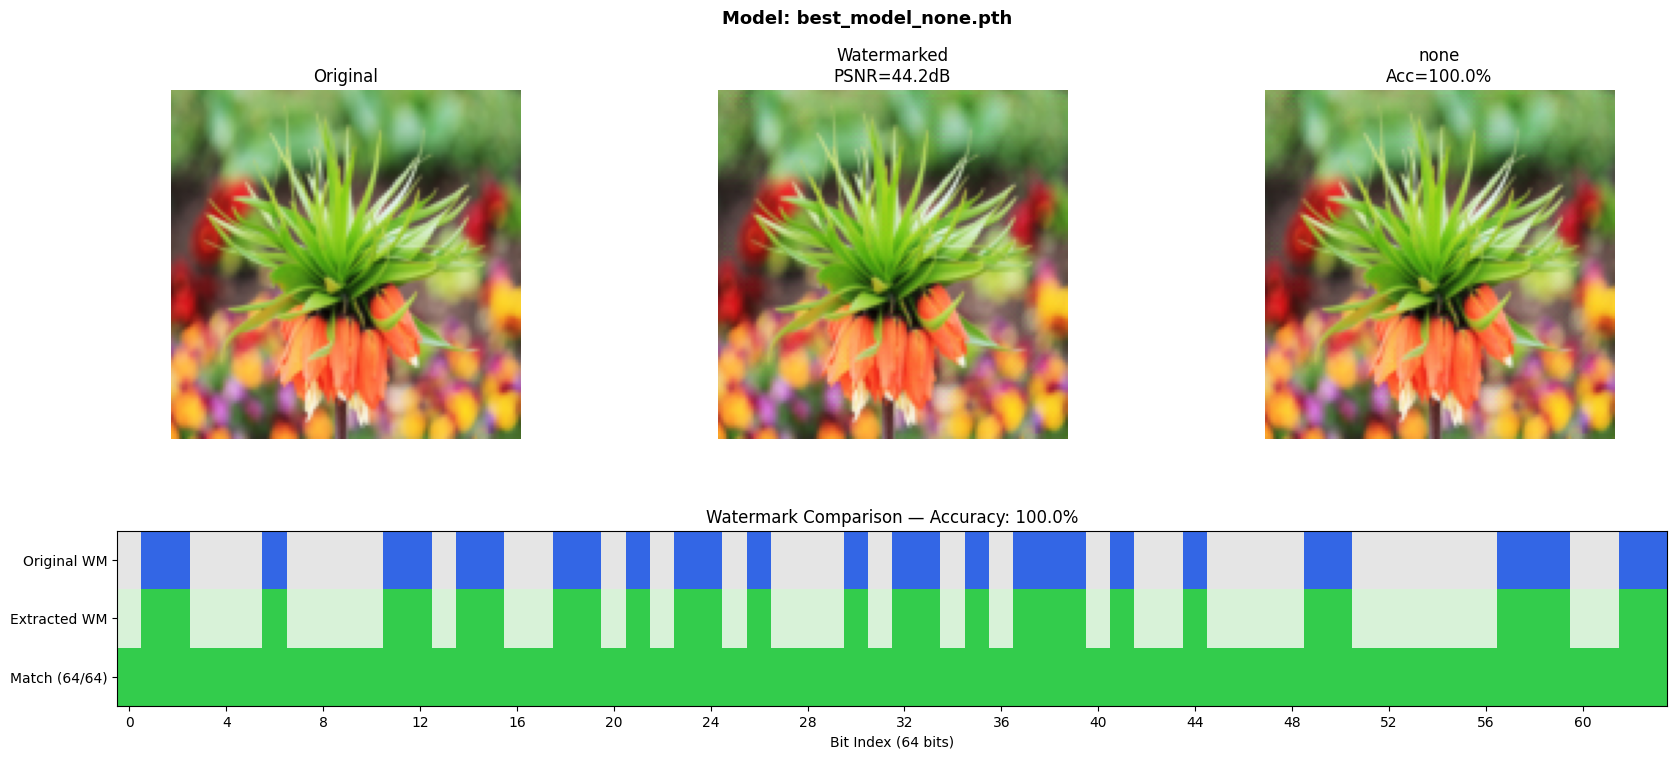


[none] PSNR=44.18dB | Acc=100.00%
  Original : 0110001000011011001101011010001011010111010010000110000001110011
  Extracted: 0110001000011011001101011010001011010111010010000110000001110011


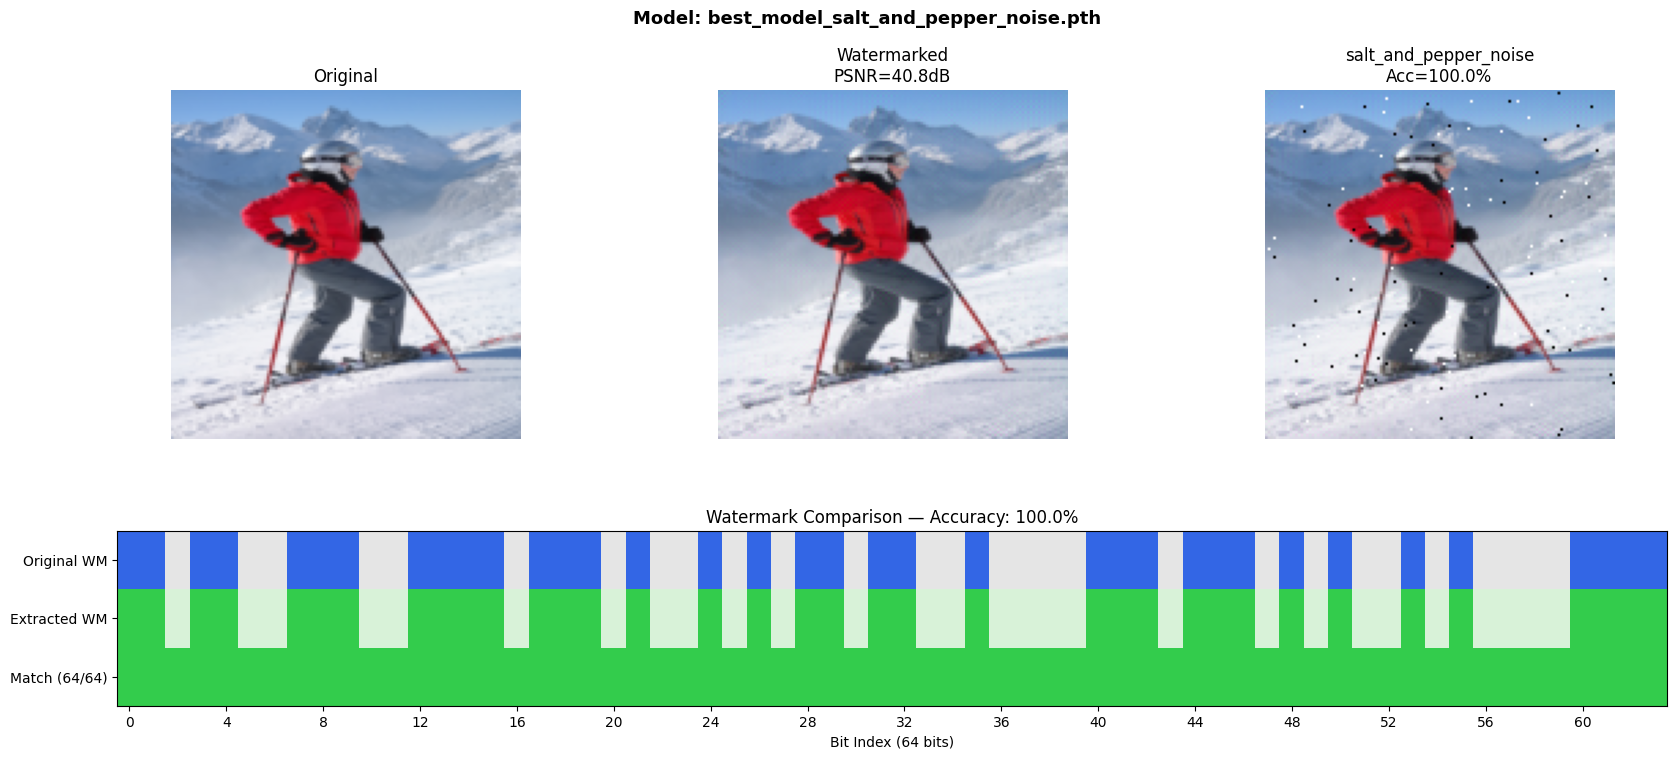


[salt_and_pepper_noise] PSNR=40.83dB | Acc=100.00%
  Original : 1101100111001111011101001010110110010000111011101010010100001111
  Extracted: 1101100111001111011101001010110110010000111011101010010100001111


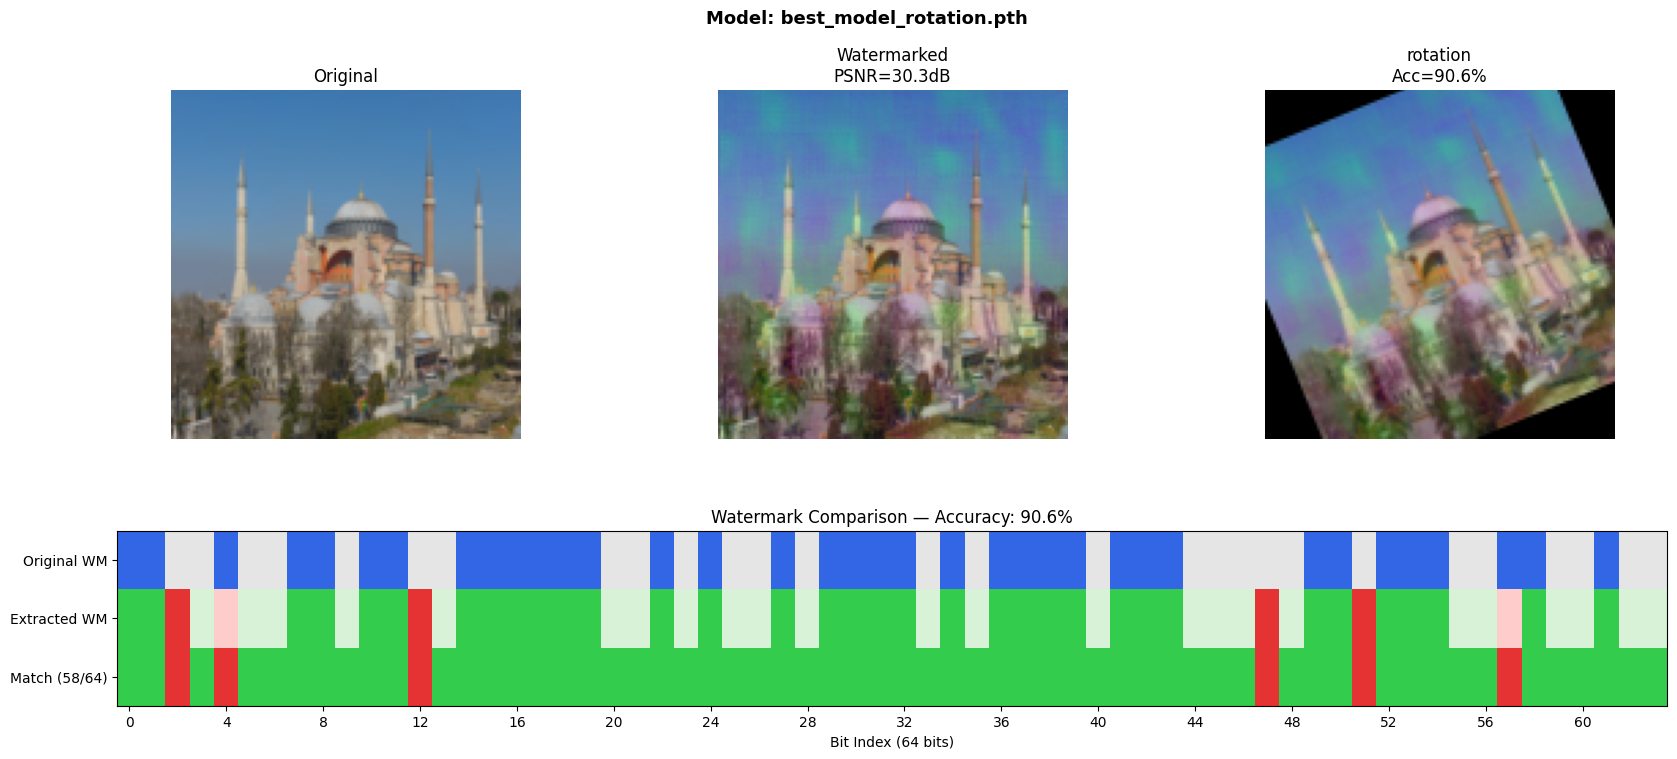


[rotation] PSNR=30.28dB | Acc=90.62%
  Original : 1100100110110011111100101001011110101111011100000110111001100100
  Extracted: 1110000110111011111100101001011110101111011100010111111000100100


In [ ]:
noise_layer = NoiseLayer()

for attack_name in attack_list:
    encoder = Encoder(in_channels=3, dim=64, num_stages=3, num_heads=4, window_size=8, watermark_length=64).to(device)
    decoder = Decoder(in_channels=3, dim=64, num_stages=3, num_heads=4, window_size=8, watermark_length=64).to(device)

    path = f'best_model_{attack_name}.pth'
    checkpoint = torch.load(path, map_location=device)
    encoder.load_state_dict(checkpoint['encoder_state'])
    decoder.load_state_dict(checkpoint['decoder_state'])
    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        img, wm = next(iter(valid_loader))
        img = img[:1].to(device)
        wm = wm[:1].to(device)

        watermarked = encoder(img, wm)
        attacked = noise_layer(watermarked, attack_type=attack_name)
        extracted = decoder(attacked)
        pred = (torch.sigmoid(extracted) > 0.5).float()

        acc = (pred == wm).float().mean().item() * 100
        mse = F.mse_loss(watermarked, img).item()
        psnr = 10 * math.log10(1.0 / (mse + 1e-10))

    orig_bits = wm.squeeze().cpu().numpy().astype(int)
    extr_bits = pred.squeeze().cpu().numpy().astype(int)
    match = (orig_bits == extr_bits).astype(int)
    num_correct = match.sum()
    num_total = len(orig_bits)

    fig = plt.figure(figsize=(20, 8))
    gs = fig.add_gridspec(2, 3, height_ratios=[3, 1.5], hspace=0.35)

    ax0 = fig.add_subplot(gs[0, 0])
    ax0.imshow(img[0].cpu().permute(1,2,0).clamp(0,1))
    ax0.set_title('Original')
    ax0.axis('off')

    ax1 = fig.add_subplot(gs[0, 1])
    ax1.imshow(watermarked[0].cpu().permute(1,2,0).clamp(0,1))
    ax1.set_title(f'Watermarked\nPSNR={psnr:.1f}dB')
    ax1.axis('off')

    ax2 = fig.add_subplot(gs[0, 2])
    ax2.imshow(attacked[0].cpu().permute(1,2,0).clamp(0,1))
    ax2.set_title(f'{attack_name}\nAcc={acc:.1f}%')
    ax2.axis('off')

    ax3 = fig.add_subplot(gs[1, :])
    colors = np.zeros((3, num_total, 3))
    for j in range(num_total):
        colors[0, j] = [0.2, 0.4, 0.9] if orig_bits[j] == 1 else [0.9, 0.9, 0.9]
        if match[j]:
            colors[1, j] = [0.2, 0.8, 0.3] if extr_bits[j] == 1 else [0.85, 0.95, 0.85]
        else:
            colors[1, j] = [0.9, 0.2, 0.2] if extr_bits[j] == 1 else [1.0, 0.8, 0.8]

        colors[2, j] = [0.2, 0.8, 0.3] if match[j] else [0.9, 0.2, 0.2]

    ax3.imshow(colors, aspect='auto', interpolation='nearest')
    ax3.set_yticks([0, 1, 2])
    ax3.set_yticklabels(['Original WM', 'Extracted WM', f'Match ({num_correct}/{num_total})'])
    ax3.set_xlabel('Bit Index (64 bits)')
    ax3.set_title(f'Watermark Comparison — Accuracy: {acc:.1f}%')
    ax3.set_xticks(range(0, num_total, 4))

    plt.suptitle(f'Model: best_model_{attack_name}.pth', fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f"\n[{attack_name}] PSNR={psnr:.2f}dB | Acc={acc:.2f}%")
    print(f"  Original : {''.join(map(str, orig_bits))}")
    print(f"  Extracted: {''.join(map(str, extr_bits))}")
